# MC-OCR Original → Clean: kiểm tra và trực quan hóa

Notebook này chỉ đọc dữ liệu. Nó hiển thị ảnh trùng/leak, bbox và transcript để giải thích quyết định giữ/xóa; đồng thời kiểm tra lại cấu trúc `dataset/MC-OCR/clean`. Chạy **Run All** từ trên xuống.

In [1]:
from pathlib import Path
from collections import defaultdict, Counter
import ast
import csv
import hashlib
import json

from PIL import Image, ImageDraw, ImageFont, ImageOps
from IPython.display import display

def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate/'dataset/MC-OCR/original').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy dataset/MC-OCR/original')

PROJECT_ROOT = find_project_root()
ORIGINAL = PROJECT_ROOT/'dataset/MC-OCR/original'
CLEAN = PROJECT_ROOT/'dataset/MC-OCR/clean'
TRAIN_IMAGES = ORIGINAL/'train_images/train_images'
VAL_IMAGES = ORIGINAL/'val_images/val_images'
REPORT = json.loads((CLEAN/'cleaning_report.json').read_text(encoding='utf-8'))
print('Original:', ORIGINAL)
print('Clean:', CLEAN)

Original: /home/ubuntu/Documents/HK1/Computer_Vision_and_Applications/project/dataset/MC-OCR/original
Clean: /home/ubuntu/Documents/HK1/Computer_Vision_and_Applications/project/dataset/MC-OCR/clean


In [2]:
def load_csv(path):
    with path.open(encoding='utf-8-sig', newline='') as handle:
        return list(csv.DictReader(handle))

ORIGINAL_ROWS = {row['img_id']: row for row in load_csv(ORIGINAL/'mcocr_train_df.csv')}
CLEAN_ROWS = {row['img_id']: row for row in load_csv(CLEAN/'train/annotations.csv')}
COLORS = {'SELLER':'#00AEEF', 'ADDRESS':'#8E44AD', 'TIMESTAMP':'#F39C12', 'TOTAL_COST':'#27AE60', 'TOTAL_TOTAL_COST':'#FF0000'}

def font(size=18):
    path=Path('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
    return ImageFont.truetype(str(path), size) if path.exists() else ImageFont.load_default()

def sha256(path):
    digest=hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024*1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def draw_main_annotations(image_path, row):
    image=Image.open(image_path).convert('RGB')
    draw=ImageDraw.Draw(image)
    polygons=ast.literal_eval(row['anno_polygons'])
    texts=row['anno_texts'].split('|||') if row['anno_texts'] else []
    labels=row['anno_labels'].split('|||') if row['anno_labels'] else []
    line_width=max(2,min(image.size)//240)
    label_font=font(max(15,min(image.size)//55))
    for polygon,text,label in zip(polygons,texts,labels):
        x,y,w,h=polygon['bbox']; color=COLORS.get(label,'#FF0000')
        draw.rectangle((x,y,x+w,y+h), outline=color, width=line_width)
        draw.text((x,max(0,y-label_font.size-5)), f'{label}: {text}', fill=color, font=label_font, stroke_width=2, stroke_fill='white')
    return image

def show_sheet(items, columns=2, cell_width=560, cell_height=680):
    rows=(len(items)+columns-1)//columns
    sheet=Image.new('RGB',(columns*cell_width,rows*cell_height),'white')
    draw=ImageDraw.Draw(sheet); title_font=font(17)
    for index,(image,title) in enumerate(items):
        row,column=divmod(index,columns); x0,y0=column*cell_width,row*cell_height
        preview=ImageOps.contain(image.convert('RGB'),(cell_width-20,cell_height-95))
        sheet.paste(preview,(x0+(cell_width-preview.width)//2,y0+90))
        draw.multiline_text((x0+8,y0+7),title,fill='black',font=title_font,spacing=3)
        draw.rectangle((x0,y0,x0+cell_width-1,y0+cell_height-1),outline='#AAAAAA',width=2)
    display(sheet)
    return sheet

## 1. Tổng quan quyết định làm sạch

In [3]:
for key,value in REPORT['counts'].items():
    print(f'{key:48s}: {value}')
print('\nNhóm duplicate train:',len(REPORT['removed_train_duplicates']))
print('Nhóm duplicate validation:',len(REPORT['removed_validation_duplicates']))
print('Nhóm leak train-validation:',len(REPORT['removed_train_validation_leaks']))
print('Nhóm duplicate vượt recognition split:',sum(item['recognition_split_crossing'] for item in REPORT['removed_train_duplicates']))

train_images_before                             : 1155
train_duplicate_files_removed                   : 33
train_validation_leaks_removed_from_train       : 20
zero_annotation_train_images_removed            : 2
train_images_after                              : 1100
validation_images_before                        : 391
validation_duplicate_files_removed              : 2
validation_images_after                         : 389
recognition_train_crops_after                   : 5002
recognition_validation_crops_after              : 1269
recognition_crop_images_after                   : 6271
token_kie_documents_after                       : 1098
token_kie_lines_after                           : 38875
token_kie_blank_transcripts_preserved           : 19155
token_kie_blank_target_transcripts_preserved    : 3014

Nhóm duplicate train: 31
Nhóm duplicate validation: 2
Nhóm leak train-validation: 20
Nhóm duplicate vượt recognition split: 8


## 2. Xem annotation của nhóm ảnh trùng train

Mỗi ảnh trùng đúng byte nhưng annotation có thể khác. Đổi `GROUP_INDEX` từ `0` đến `30` để xem từng nhóm. `KEEP` được chọn theo: giữ phía recognition-validation nếu nhóm vượt split; nếu không thì ưu tiên đủ bốn nhãn, số vùng, độ dài transcript và điểm quality.

{
  "sha256": "04cc3e4c3aefb85c9ef8459226d6e2278eec2eb6677f937f68503f0f1d381e5a",
  "kept": "mcocr_public_145014ezyfv.jpg",
  "removed": [
    "mcocr_public_145014crsgq.jpg"
  ],
  "recognition_split_crossing": false,
  "kept_score": [
    4,
    5,
    87,
    0.640287
  ]
}


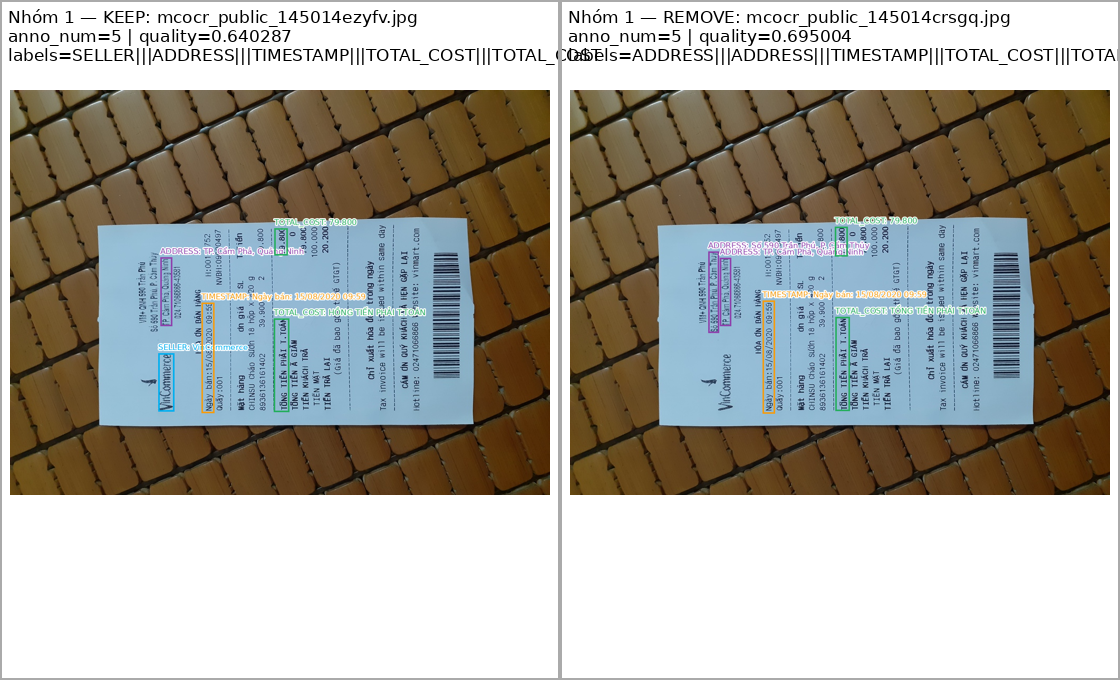

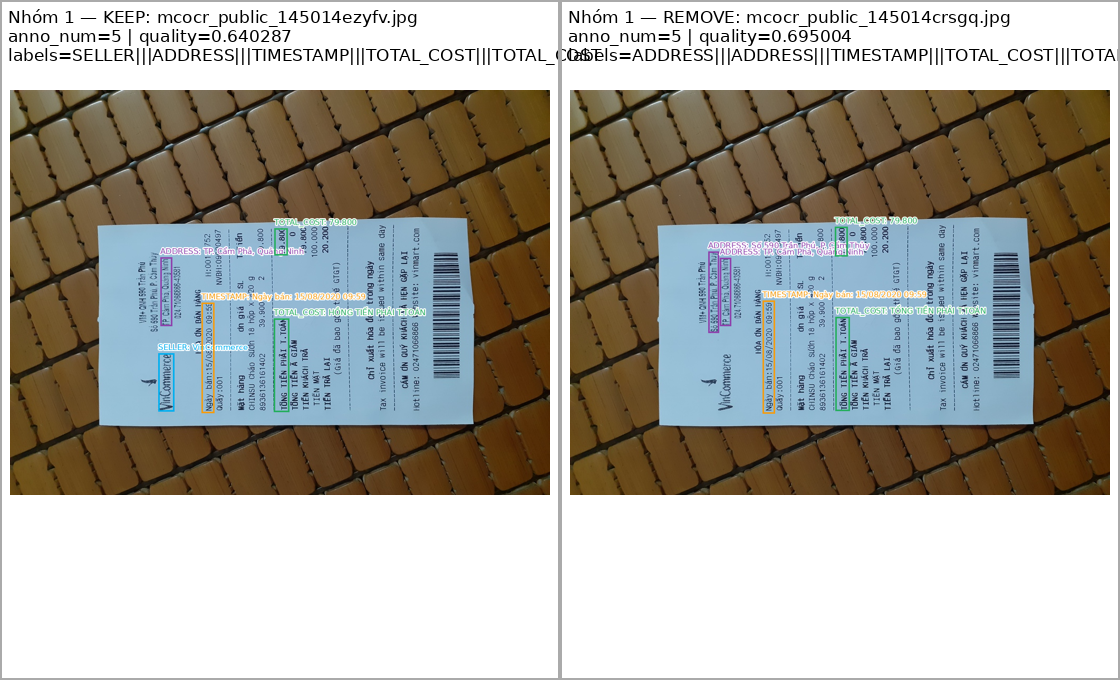

In [4]:
GROUP_INDEX=0
group=REPORT['removed_train_duplicates'][GROUP_INDEX]
items=[]
for name in [group['kept'],*group['removed']]:
    row=ORIGINAL_ROWS[name]
    status='KEEP' if name==group['kept'] else 'REMOVE'
    title=f"Nhóm {GROUP_INDEX+1} — {status}: {name}\nanno_num={row['anno_num']} | quality={row['anno_image_quality']}\nlabels={row['anno_labels']}"
    items.append((draw_main_annotations(TRAIN_IMAGES/name,row),title))
print(json.dumps(group,ensure_ascii=False,indent=2))
show_sheet(items,columns=2)

## 3. Duplicate validation và leak train–validation

Đổi `VAL_DUPLICATE_INDEX` từ `0..1` hoặc `LEAK_INDEX` từ `0..19`. Validation chưa có ground truth nên chỉ so sánh ảnh.

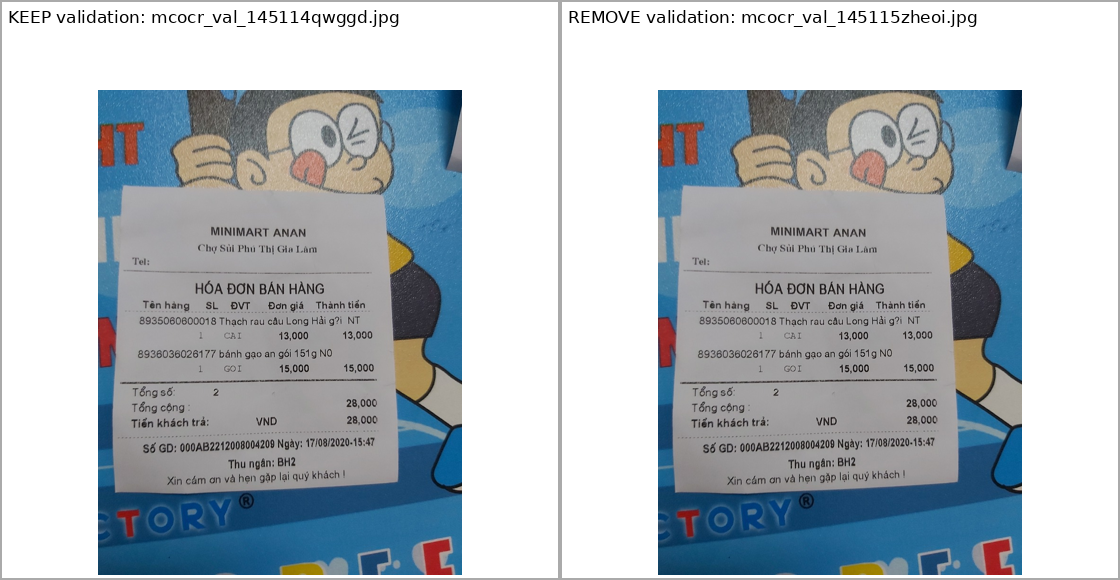

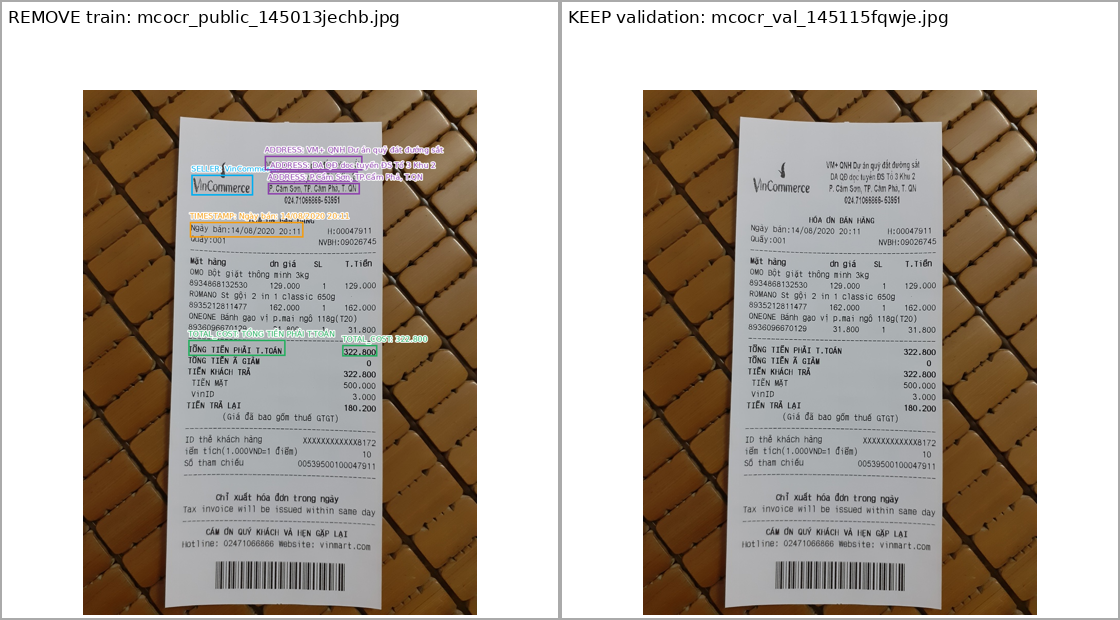

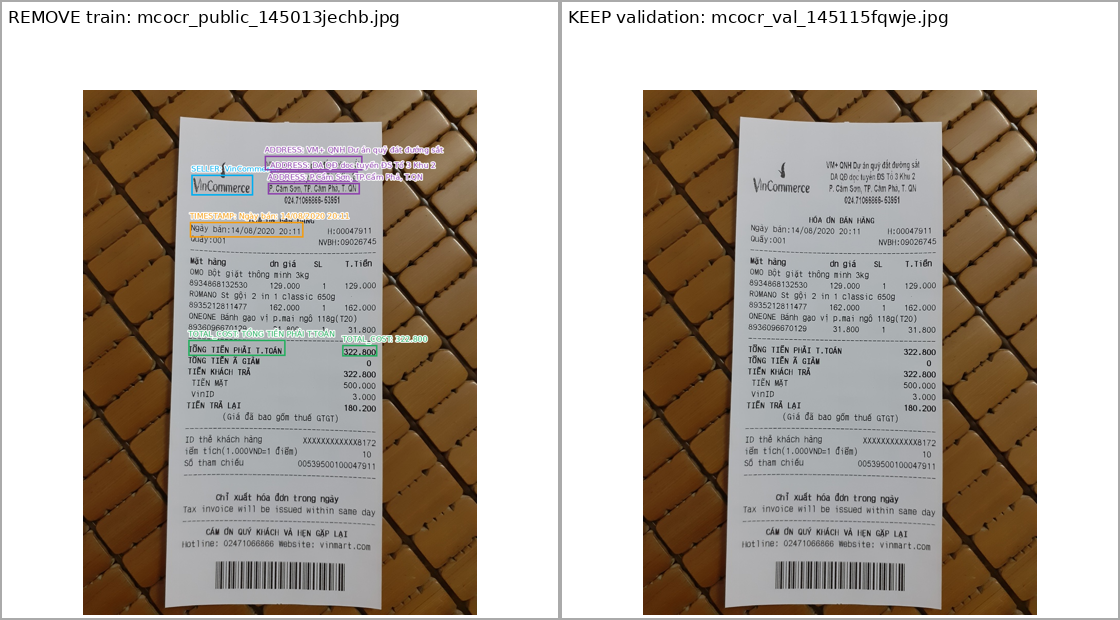

In [5]:
VAL_DUPLICATE_INDEX=0
g=REPORT['removed_validation_duplicates'][VAL_DUPLICATE_INDEX]
items=[]
for name in [g['kept'],*g['removed']]:
    status='KEEP' if name==g['kept'] else 'REMOVE'
    items.append((Image.open(VAL_IMAGES/name).convert('RGB'),f'{status} validation: {name}'))
show_sheet(items,columns=2,cell_height=580)

LEAK_INDEX=0
g=REPORT['removed_train_validation_leaks'][LEAK_INDEX]
train_name=g['removed_from_train'][0]; val_name=g['kept_in_validation'][0]
assert sha256(TRAIN_IMAGES/train_name)==sha256(VAL_IMAGES/val_name)
show_sheet([
    (draw_main_annotations(TRAIN_IMAGES/train_name,ORIGINAL_ROWS[train_name]),f'REMOVE train: {train_name}'),
    (Image.open(VAL_IMAGES/val_name).convert('RGB'),f'KEEP validation: {val_name}'),
],columns=2,cell_height=620)

## 4. Hai ảnh `anno_num=0` và bốn TSV bị thiếu

Hai ảnh không có nhãn được loại khỏi train. `iwhec` nhòe nặng; `jndnz` còn đọc được nhưng không có ground truth đáng tin. Hai ảnh `uqtmx`, `mwhyh` vẫn có nhãn receipt-level trong CSV nên được giữ ở train, nhưng bị loại khỏi `token_kie` vì không thể tái tạo full-token/OTHER TSV một cách trung thực.

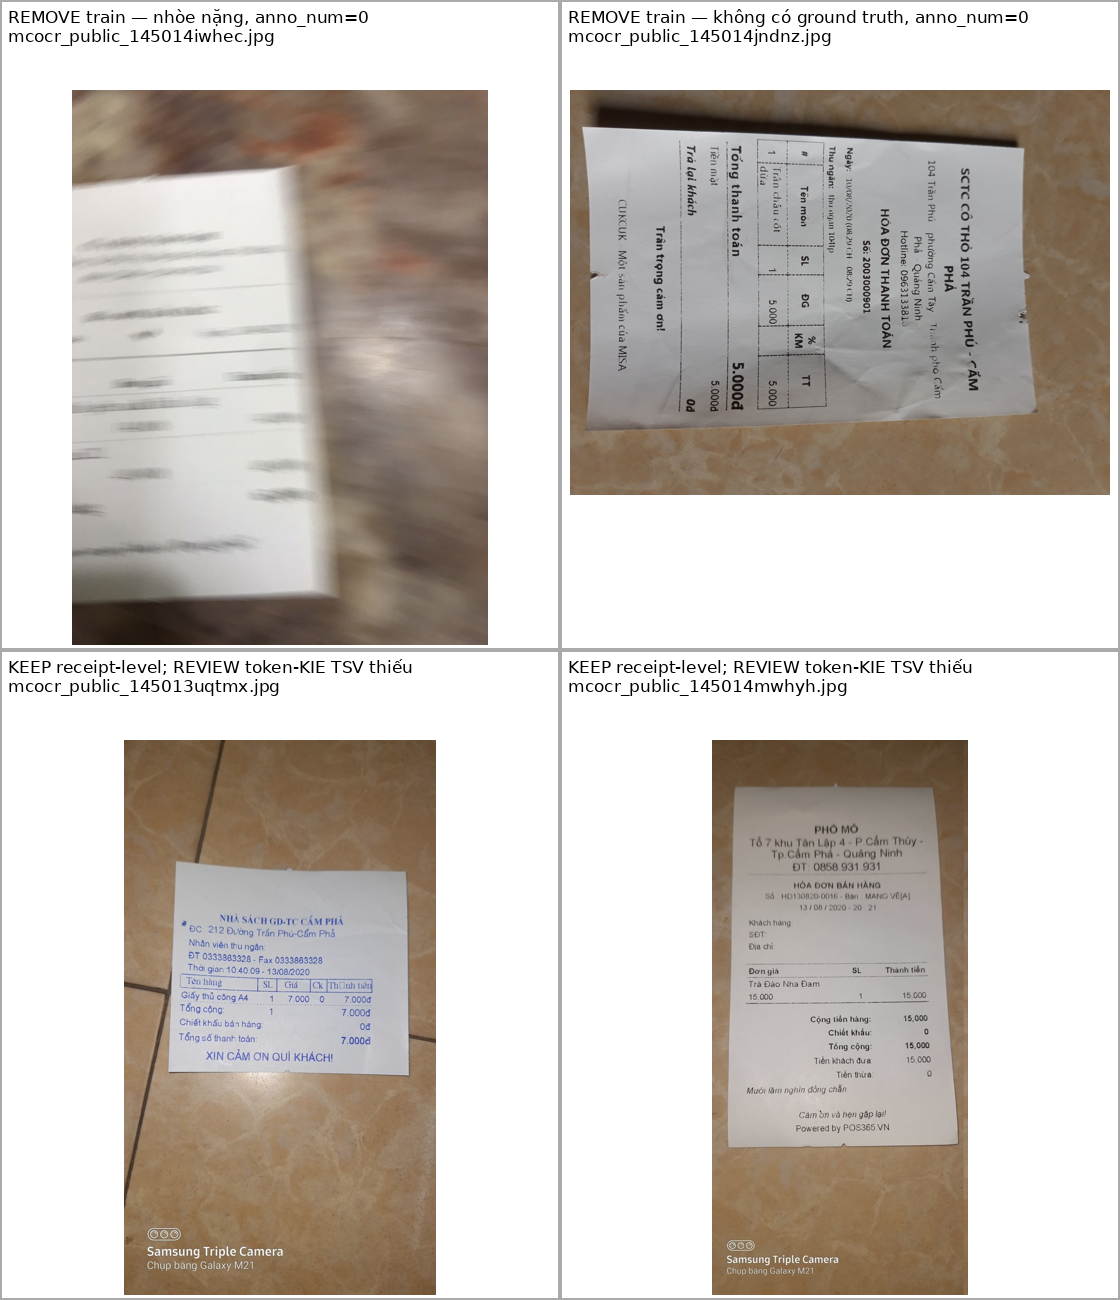

Danh sách review Clean:
mcocr_public_145013uqtmx.jpg
mcocr_public_145014mwhyh.jpg



In [6]:
cases=[
 ('mcocr_public_145014iwhec.jpg','REMOVE train — nhòe nặng, anno_num=0'),
 ('mcocr_public_145014jndnz.jpg','REMOVE train — không có ground truth, anno_num=0'),
 ('mcocr_public_145013uqtmx.jpg','KEEP receipt-level; REVIEW token-KIE TSV thiếu'),
 ('mcocr_public_145014mwhyh.jpg','KEEP receipt-level; REVIEW token-KIE TSV thiếu'),
]
show_sheet([(Image.open(TRAIN_IMAGES/name).convert('RGB'),title+'\n'+name) for name,title in cases],columns=2,cell_height=650)
print('Danh sách review Clean:')
print((CLEAN/'review/token_kie_missing_annotations.txt').read_text(encoding='utf-8'))

## 5. Typo `TOTAL_TOTAL_COST` trước và sau

Vùng đỏ trong Original là nhãn sai chính tả; Clean chuẩn hóa thành `TOTAL_COST`.

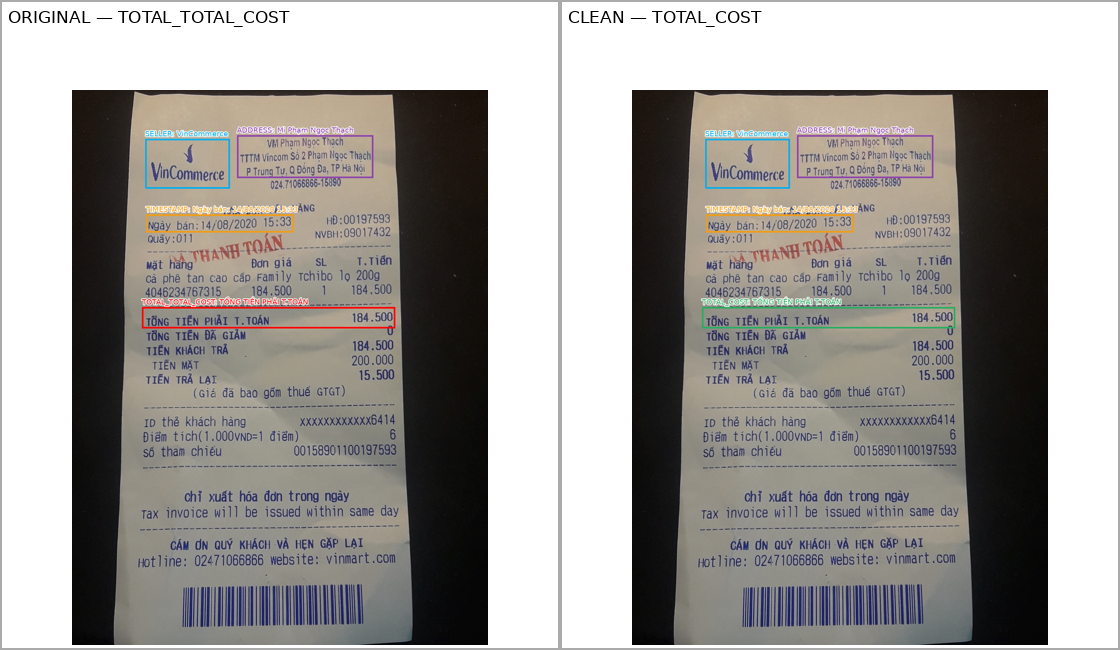

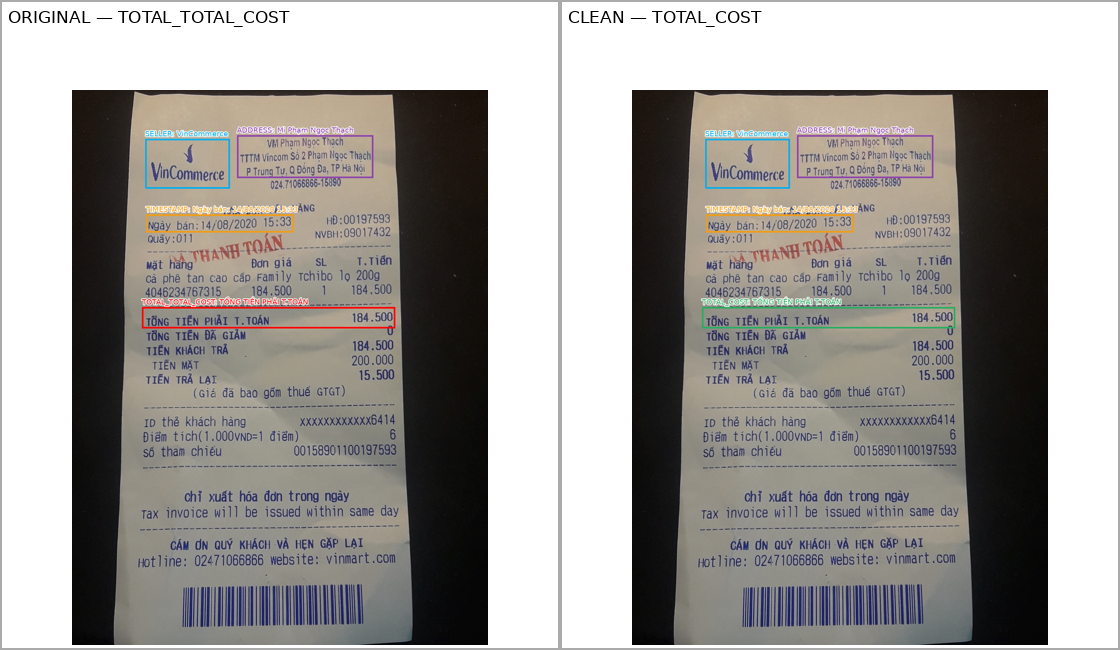

In [7]:
name='mcocr_public_145013kzjew.jpg'
show_sheet([
 (draw_main_annotations(TRAIN_IMAGES/name,ORIGINAL_ROWS[name]),'ORIGINAL — TOTAL_TOTAL_COST'),
 (draw_main_annotations(CLEAN/'train/images'/name,CLEAN_ROWS[name]),'CLEAN — TOTAL_COST'),
],columns=2,cell_height=650)

## 6. Validation đang chờ OCR và verify

Chuỗi `abc abc abc` không được mang sang Clean. File mới đánh dấu rõ trạng thái pending.

In [8]:
original_val=load_csv(ORIGINAL/'mcocr_val_sample_df.csv')
pending_val=load_csv(CLEAN/'validation/annotations_pending.csv')
print('Original placeholder abc:',sum(r['anno_texts']=='abc abc abc' for r in original_val),'/',len(original_val))
print('Clean pending:',sum(r['annotation_status']=='pending_ocr_and_human_verification' for r in pending_val),'/',len(pending_val))
for row in pending_val[:5]:print(row)

Original placeholder abc: 391 / 391
Clean pending: 389 / 389
{'img_id': 'mcocr_val_145114xmicn.jpg', 'annotation_status': 'pending_ocr_and_human_verification', 'anno_image_quality': '', 'anno_texts': ''}
{'img_id': 'mcocr_val_145114qcosd.jpg', 'annotation_status': 'pending_ocr_and_human_verification', 'anno_image_quality': '', 'anno_texts': ''}
{'img_id': 'mcocr_val_145114zizpx.jpg', 'annotation_status': 'pending_ocr_and_human_verification', 'anno_image_quality': '', 'anno_texts': ''}
{'img_id': 'mcocr_val_145114budzl.jpg', 'annotation_status': 'pending_ocr_and_human_verification', 'anno_image_quality': '', 'anno_texts': ''}
{'img_id': 'mcocr_val_145114qwggd.jpg', 'annotation_status': 'pending_ocr_and_human_verification', 'anno_image_quality': '', 'anno_texts': ''}


## 7. Kiểm tra độc lập bản Clean

Token-KIE vẫn giữ các transcript rỗng vì xóa tự động sẽ làm mất vùng có nhãn. Đây là nhánh tùy chọn cần re-OCR và con người kiểm tra sau.

In [9]:
clean_train={p.name:p for p in (CLEAN/'train/images').glob('*.jpg')}
clean_val={p.name:p for p in (CLEAN/'validation/images').glob('*.jpg')}
assert set(clean_train)==set(CLEAN_ROWS)
assert len(clean_train)==1100 and len(clean_val)==389
train_hashes=defaultdict(list);val_hashes=defaultdict(list)
for name,path in clean_train.items():train_hashes[sha256(path)].append(name)
for name,path in clean_val.items():val_hashes[sha256(path)].append(name)
assert all(len(v)==1 for v in train_hashes.values())
assert all(len(v)==1 for v in val_hashes.values())
assert not(set(train_hashes)&set(val_hashes))
assert all(int(row['anno_num'])>0 for row in CLEAN_ROWS.values())
assert all('TOTAL_TOTAL_COST' not in row['anno_labels'] for row in CLEAN_ROWS.values())
rec_train=(CLEAN/'recognition/train.tsv').read_text(encoding='utf-8').splitlines()
rec_val=(CLEAN/'recognition/validation.tsv').read_text(encoding='utf-8').splitlines()
crop_files={p.name for p in (CLEAN/'recognition/images').glob('*.jpg')}
manifest_files={line.split('\t',1)[0] for line in rec_train+rec_val}
assert crop_files==manifest_files
token_images={p.stem for p in (CLEAN/'token_kie/images').glob('*.jpg')}
token_tsv={p.stem for p in (CLEAN/'token_kie/annotations').glob('*.tsv')}
assert token_images==token_tsv and len(token_images)==1098
print('Train:',len(clean_train),'ảnh có nhãn')
print('Validation:',len(clean_val),'ảnh chờ annotate')
print('Recognition:',len(rec_train),'train crops +',len(rec_val),'validation crops')
print('Token-KIE:',len(token_images),'tài liệu')
print('Duplicate trong split: 0 | Leak train-validation: 0')
print('anno_num=0: 0 | Nhãn TOTAL_TOTAL_COST: 0')
print('Token transcript rỗng còn giữ:',REPORT['counts']['token_kie_blank_transcripts_preserved'])
print('Trong đó vùng nhãn mục tiêu:',REPORT['counts']['token_kie_blank_target_transcripts_preserved'])

Train: 1100 ảnh có nhãn
Validation: 389 ảnh chờ annotate
Recognition: 5002 train crops + 1269 validation crops
Token-KIE: 1098 tài liệu
Duplicate trong split: 0 | Leak train-validation: 0
anno_num=0: 0 | Nhãn TOTAL_TOTAL_COST: 0
Token transcript rỗng còn giữ: 19155
Trong đó vùng nhãn mục tiêu: 3014
